# Preprocessing Workflow


🎯 This exercise will guide you through the preprocessing workflow. Step by step, feature by feature, you will investigate the dataset and take preprocessing decisions accordingly.

🌤 We stored the `ML_Houses_dataset.csv` [here](https://wagon-public-datasets.s3.amazonaws.com/Machine%20Learning%20Datasets/ML_Houses_dataset.csv) in the cloud.

👇 Run the code down below to load the dataset and features you will be working with.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
# Loading the dataset
data = pd.read_csv('raw_data/covtype.csv')

# Showing the first five rows
data.head()

# Split into features (X) and target (y)
X = data.drop('Cover_Type', axis=1)  # Drop the target column 'Cover_Type'
y = data['Cover_Type']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state = 42)

In [3]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, LabelEncoder


# Initialize scalers
standard_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()
robust_scaler = RobustScaler()
label_encoder = LabelEncoder()

# 1. StandardScaler for Elevation
X_train['Elevation'] = standard_scaler.fit_transform(X_train[['Elevation']])
X_test['Elevation'] = standard_scaler.transform(X_test[['Elevation']])

# 2. MinMaxScaler for Aspect
X_train['Aspect'] = min_max_scaler.fit_transform(X_train[['Aspect']])
X_test['Aspect'] = min_max_scaler.transform(X_test[['Aspect']])

# 3. StandardScaler for Slope
X_train['Slope'] = standard_scaler.fit_transform(X_train[['Slope']])
X_test['Slope'] = standard_scaler.transform(X_test[['Slope']])

# 4. RobustScaler for Horizontal_Distance_To_Hydrology
X_train['Horizontal_Distance_To_Hydrology'] = robust_scaler.fit_transform(X_train[['Horizontal_Distance_To_Hydrology']])
X_test['Horizontal_Distance_To_Hydrology'] = robust_scaler.transform(X_test[['Horizontal_Distance_To_Hydrology']])

# 5. RobustScaler for Vertical_Distance_To_Hydrology
X_train['Vertical_Distance_To_Hydrology'] = robust_scaler.fit_transform(X_train[['Vertical_Distance_To_Hydrology']])
X_test['Vertical_Distance_To_Hydrology'] = robust_scaler.transform(X_test[['Vertical_Distance_To_Hydrology']])

# 6. RobustScaler for Horizontal_Distance_To_Roadways
X_train['Horizontal_Distance_To_Roadways'] = robust_scaler.fit_transform(X_train[['Horizontal_Distance_To_Roadways']])
X_test['Horizontal_Distance_To_Roadways'] = robust_scaler.transform(X_test[['Horizontal_Distance_To_Roadways']])

# 7. MinMaxScaler for Hillshade_9am, Hillshade_Noon, Hillshade_3pm
X_train['Hillshade_9am'] = min_max_scaler.fit_transform(X_train[['Hillshade_9am']])
X_test['Hillshade_9am'] = min_max_scaler.transform(X_test[['Hillshade_9am']])

X_train['Hillshade_Noon'] = min_max_scaler.fit_transform(X_train[['Hillshade_Noon']])
X_test['Hillshade_Noon'] = min_max_scaler.transform(X_test[['Hillshade_Noon']])

X_train['Hillshade_3pm'] = min_max_scaler.fit_transform(X_train[['Hillshade_3pm']])
X_test['Hillshade_3pm'] = min_max_scaler.transform(X_test[['Hillshade_3pm']])


# 8. RobustScaler for Horizontal_Distance_To_Fire_Points
X_train['Horizontal_Distance_To_Fire_Points'] = robust_scaler.fit_transform(X_train[['Horizontal_Distance_To_Fire_Points']])
X_test['Horizontal_Distance_To_Fire_Points'] = robust_scaler.transform(X_test[['Horizontal_Distance_To_Fire_Points']])

📚 Take the time to do a ***preliminary investigation*** of the features by reading the ***dataset description*** available [here](https://wagon-public-datasets.s3.amazonaws.com/Machine%20Learning%20Datasets/ML_Houses_dataset_description.txt). Make sure to refer to it throughout the day.

## (1) Duplicates

ℹ️ ***Duplicates in datasets cause data leakage.*** 

👉 It is important to locate and remove duplicates.

❓ How many duplicated rows are there in the dataset ❓

<i>Save your answer under variable name `duplicate_count`.</i>

In [3]:
duplicate_count = len(data) - len(data.drop_duplicates()) # Original data length minus data length without duplicates
duplicate_count

0

❓ Remove the duplicates from the dataset. Overwite the dataframe `data`❓

## (2) Missing data

❓ Print the percentage of missing values for every column of the dataframe. ❓

In [6]:
round(data.isnull().sum().sort_values(ascending=False)/len(data),2) #NaN percentage for each column

Elevation                             0.0
Soil_Type28                           0.0
Soil_Type17                           0.0
Soil_Type18                           0.0
Soil_Type19                           0.0
Soil_Type20                           0.0
Soil_Type21                           0.0
Soil_Type22                           0.0
Soil_Type23                           0.0
Soil_Type24                           0.0
Soil_Type25                           0.0
Soil_Type26                           0.0
Soil_Type27                           0.0
Soil_Type29                           0.0
Soil_Type15                           0.0
Soil_Type30                           0.0
Soil_Type31                           0.0
Soil_Type32                           0.0
Soil_Type33                           0.0
Soil_Type34                           0.0
Soil_Type35                           0.0
Soil_Type36                           0.0
Soil_Type37                           0.0
Soil_Type38                       

In [51]:
data.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


<AxesSubplot:>

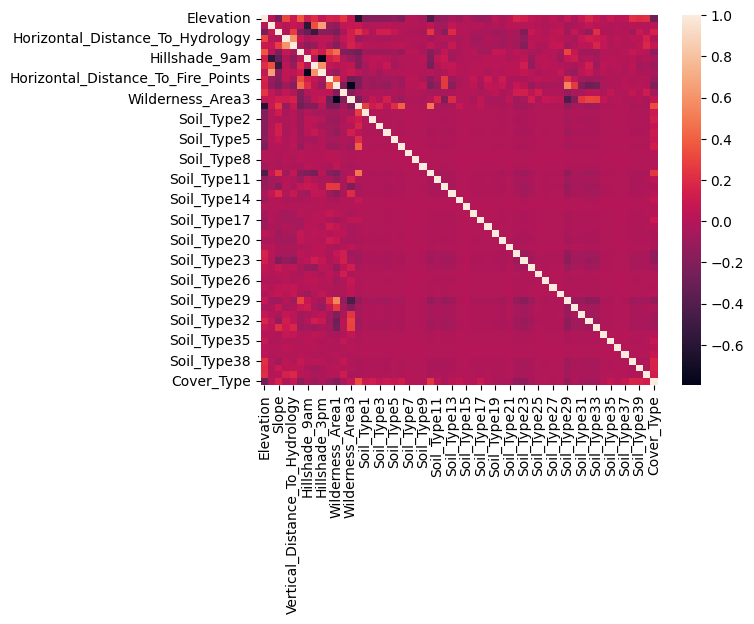

In [55]:
# 1. StandardScaler for Elevation
X_test['Elevation'] = standard_scaler.transform(X_test[['Elevation']])

# 2. MinMaxScaler for Aspect
X_test['Aspect'] = min_max_scaler.transform(X_test[['Aspect']])

# 3. StandardScaler for Slope
X_test['Slope'] = standard_scaler.transform(X_test[['Slope']])

# 4. RobustScaler for Horizontal_Distance_To_Hydrology
X_test['Horizontal_Distance_To_Hydrology'] = robust_scaler.transform(X_test[['Horizontal_Distance_To_Hydrology']])

# 5. RobustScaler for Vertical_Distance_To_Hydrology
X_test['Vertical_Distance_To_Hydrology'] = robust_scaler.transform(X_test[['Vertical_Distance_To_Hydrology']])

# 6. RobustScaler for Horizontal_Distance_To_Roadways
X_test['Horizontal_Distance_To_Roadways'] = robust_scaler.transform(X_test[['Horizontal_Distance_To_Roadways']])

# 7. MinMaxScaler for Hillshade_9am, Hillshade_Noon, Hillshade_3pm
X_test['Hillshade_9am'] = min_max_scaler.transform(X_test[['Hillshade_9am']])
X_test['Hillshade_Noon'] = min_max_scaler.transform(X_test[['Hillshade_Noon']])
X_test['Hillshade_3pm'] = min_max_scaler.transform(X_test[['Hillshade_3pm']])

# 8. RobustScaler for Horizontal_Distance_To_Fire_Points
X_test['Horizontal_Distance_To_Fire_Points'] = robust_scaler.transform(X_test[['Horizontal_Distance_To_Fire_Points']])

<AxesSubplot:xlabel='Aspect'>

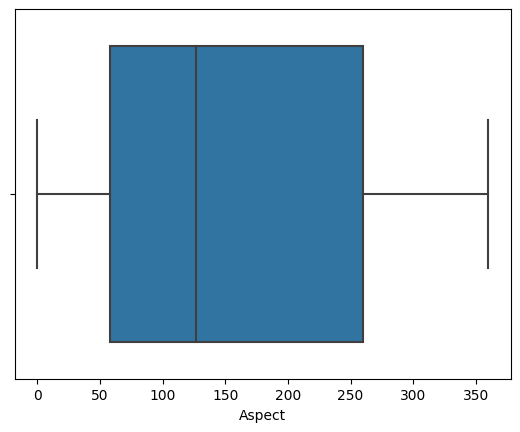

In [20]:
#there is no outliers and it is not normailzed so we should use MinMaxScaler
sns.boxplot(x=data['Aspect'])
# data['Aspect'].hist()

<AxesSubplot:>

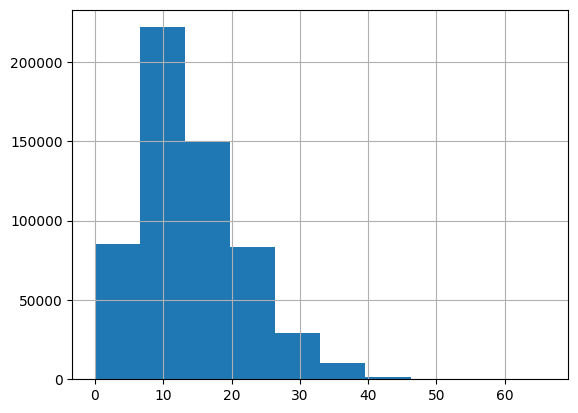

In [23]:
# we should use RobustScaler because we have outliers
sns.boxplot(x=data['Slope'])
data['Slope'].hist()

<AxesSubplot:>

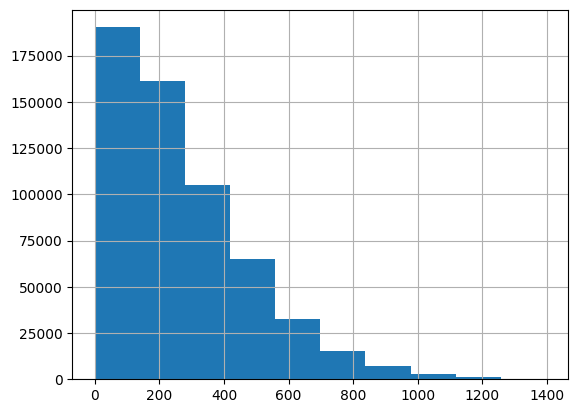

In [25]:
# we should use RobustScaler because we have outliers
sns.boxplot(x=data['Horizontal_Distance_To_Hydrology'])
data['Horizontal_Distance_To_Hydrology'].hist()

<AxesSubplot:xlabel='Vertical_Distance_To_Hydrology'>

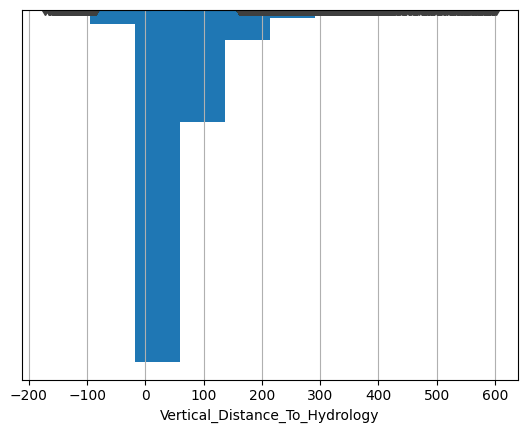

In [28]:
# we should use RobustScaler because we have outliers
sns.boxplot(x=data['Vertical_Distance_To_Hydrology'])
data['Vertical_Distance_To_Hydrology'].hist()

<AxesSubplot:>

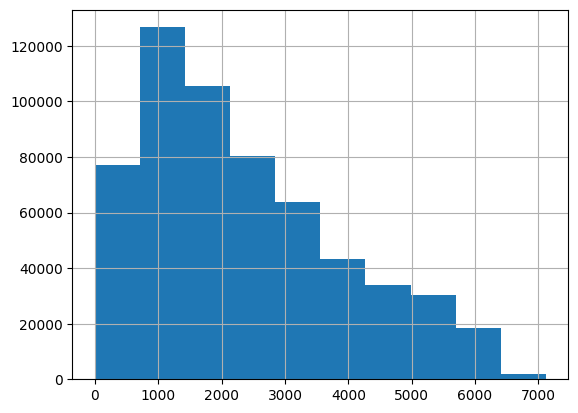

In [31]:
# we should use MinMaxScaler
# sns.boxplot(x=data['Horizontal_Distance_To_Roadways'])
data['Horizontal_Distance_To_Roadways'].hist()

<AxesSubplot:xlabel='Hillshade_9am'>

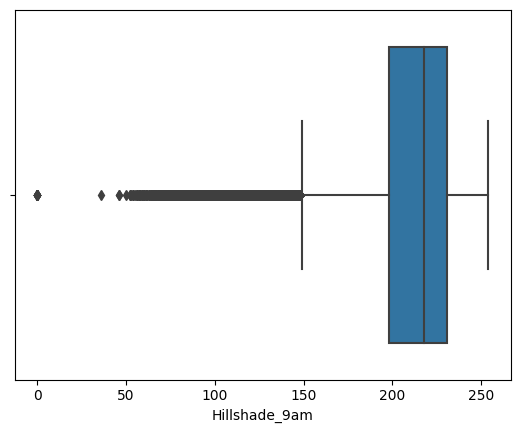

In [33]:
# we should use RobustScaler because we have outliers
sns.boxplot(x=data['Hillshade_9am'])
data['Hillshade_9am'].hist()

<AxesSubplot:xlabel='Hillshade_Noon'>

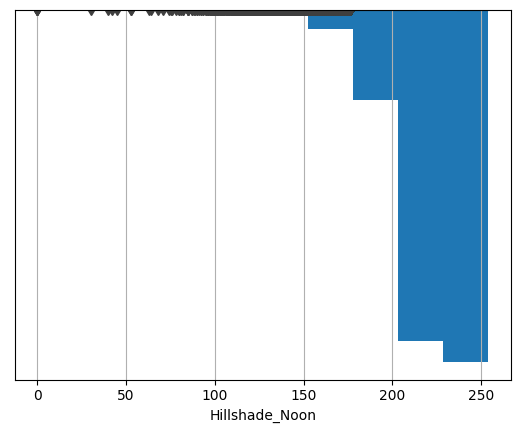

In [37]:
# we should use RobustScaler because we have outliers
sns.boxplot(x=data['Hillshade_Noon'])
data['Hillshade_Noon'].hist()

<AxesSubplot:xlabel='Hillshade_3pm'>

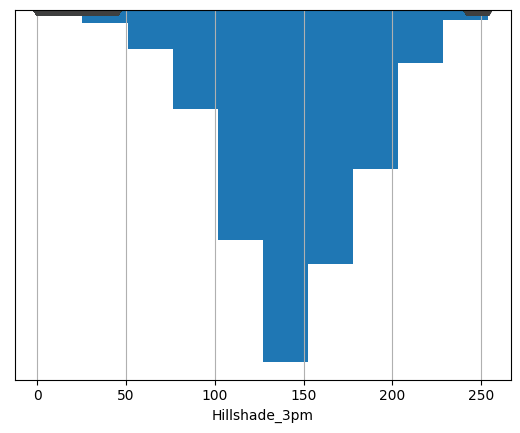

In [40]:
# we should use RobustScaler because we have outliers
sns.boxplot(x=data['Hillshade_3pm'])
data['Hillshade_3pm'].hist()

<AxesSubplot:xlabel='Horizontal_Distance_To_Fire_Points'>

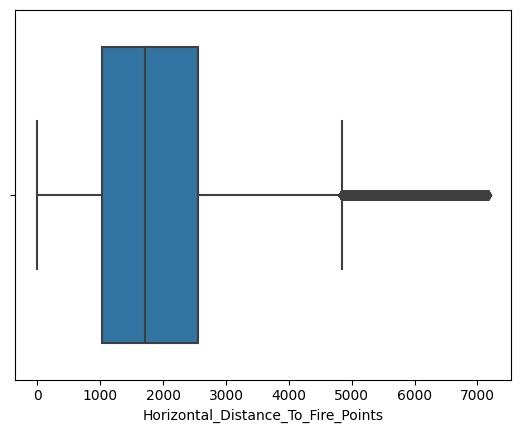

In [42]:
# we should use RobustScaler because we have outliers
sns.boxplot(x=data['Horizontal_Distance_To_Fire_Points'])
# data['Horizontal_Distance_To_Fire_Points'].hist()

<AxesSubplot:>

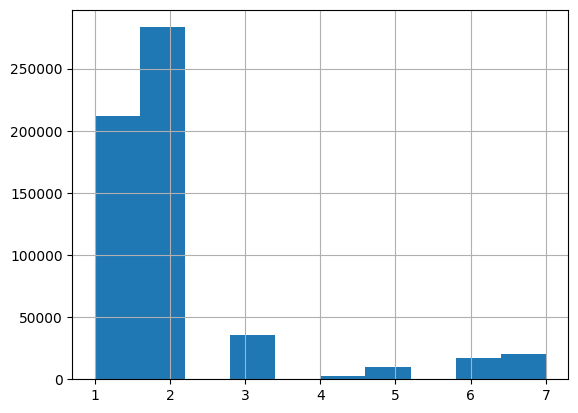

In [47]:
# we should use RobustScaler because we have outliers
# sns.boxplot(x=data['Cover_Type'])
data['Cover_Type'].hist()